In [30]:
import os
import math
from define_models import baselines
import matplotlib.pyplot as plt
from IPython.display import display
# from critdd import Diagram, Diagrams
from collections import defaultdict
from numbers import Number
import texfig as tf
from texfig import TMLR_textwidth
import os
import pandas as pd
import numpy as np
import h5py
from benchmark_analysis import load_estim

In [31]:
output_dir = "Projects/mislabeled-benchmark/ecai-output-sigmoid"

In [32]:
result_dirs = [
    (
        "weak/klm",
        os.path.join(os.path.expanduser("~"), f"{output_dir}/weak/klm"),
    ),
    # (
    #     "noise/klm",
    #     os.path.join(os.path.expanduser("~"), f"{output_dir}/noise/klm"),
    # ),
]


In [33]:
def custom_grid(axis):
    axis.grid(c="#f2f2f2", which="both")
    axis.set_axisbelow(True)

In [34]:
all_results = dict()

In [35]:
all_results['allclass'] = dict()
for prefix, result_dir in result_dirs:
    all_results['allclass'][prefix] = load_estim(
        result_dir=result_dir
    )

In [36]:
detectors = np.unique(
    np.concatenate([r.detector_name.unique() for r in all_results['allclass'].values()])
)
datasets = np.unique(np.concatenate([r.dataset_name.unique() for r in all_results['allclass'].values()]))

detectors_nobaseline = list(set(detectors) - set(baselines + ["random"]))

len(detectors), detectors, len(detectors_nobaseline), detectors_nobaseline, len(
    datasets
), datasets

(11,
 array(['gold', 'klm_aum', 'klm_aum_calibrated_sigmoid_0.2',
        'klm_cleanlab', 'klm_cleanlab_calibrated_sigmoid_0.2',
        'klm_consensus', 'klm_consensus_calibrated_sigmoid_0.2',
        'klm_smallloss', 'klm_smallloss_calibrated_sigmoid_0.2', 'none',
        'silver'], dtype=object),
 8,
 ['klm_consensus_calibrated_sigmoid_0.2',
  'klm_aum_calibrated_sigmoid_0.2',
  'klm_aum',
  'klm_cleanlab_calibrated_sigmoid_0.2',
  'klm_cleanlab',
  'klm_smallloss',
  'klm_consensus',
  'klm_smallloss_calibrated_sigmoid_0.2'],
 19,
 array(['agnews', 'amazon', 'bank-marketing', 'basketball', 'bioresponse',
        'census', 'commercial', 'hausa', 'imdb', 'mushroom', 'phishing',
        'professor_teacher', 'sms', 'spambase', 'tennis', 'trec', 'yelp',
        'yoruba', 'youtube'], dtype=object))

In [37]:
d_base_model_map = dict()
d_detect_map = dict()

for d in detectors_nobaseline:
    s = d.split("_")
    if len(s) >= 2:
        d_base_model_map[d] = s[0]
    else:
        d_base_model_map[d] = "klm"

    d_detect_map[d] = " ".join(s[1:3])

detector_suffixes = np.unique(list(d_detect_map.values()))
detector_base = np.unique([v.split(" ")[0] for v in detector_suffixes])
d_base_model_map, d_detect_map, detector_suffixes, detector_base

({'klm_consensus_calibrated_sigmoid_0.2': 'klm',
  'klm_aum_calibrated_sigmoid_0.2': 'klm',
  'klm_aum': 'klm',
  'klm_cleanlab_calibrated_sigmoid_0.2': 'klm',
  'klm_cleanlab': 'klm',
  'klm_smallloss': 'klm',
  'klm_consensus': 'klm',
  'klm_smallloss_calibrated_sigmoid_0.2': 'klm'},
 {'klm_consensus_calibrated_sigmoid_0.2': 'consensus calibrated',
  'klm_aum_calibrated_sigmoid_0.2': 'aum calibrated',
  'klm_aum': 'aum',
  'klm_cleanlab_calibrated_sigmoid_0.2': 'cleanlab calibrated',
  'klm_cleanlab': 'cleanlab',
  'klm_smallloss': 'smallloss',
  'klm_consensus': 'consensus',
  'klm_smallloss_calibrated_sigmoid_0.2': 'smallloss calibrated'},
 array(['aum', 'aum calibrated', 'cleanlab', 'cleanlab calibrated',
        'consensus', 'consensus calibrated', 'smallloss',
        'smallloss calibrated'], dtype='<U20'),
 array(['aum', 'cleanlab', 'consensus', 'smallloss'], dtype='<U9'))

In [38]:
detect_pretty_name = {
    "agra": "AGRA",
    "aum": "AUM",
    "calibrated": "(calibrated)",
    "noisy": "",
    "adjusted": "(adjusted)",
    "cleanlab": "Cleanlab",
    "consensus": "Consensus",
    "forget": "Forget scores",
    "influence": "Influence",
    "representer": "Representer",
    "smallloss": "Small loss",
    "tracin": "TracIn",
    "vosg": "VoSG",
}

bm_pretty_name = {"klm": "KLM", "gb": "GBT"}

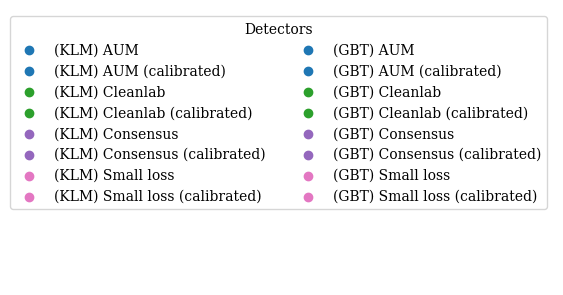

In [39]:
from matplotlib import colormaps

# tab_colors = colormaps["tab20"]
tab_colors = colormaps["tab10"]


def detector_color(detector_name):
    base = detector_name.split(" ")[0]
    mapping = {
        d: tab_colors.colors[2 * i % len(tab_colors.colors)]
        for i, d in enumerate(detector_base)
    }
    return mapping[base]


# detector_colors = {
#     d: tab_colors.colors[i % len(tab_colors.colors)]
#     for i, d in enumerate(detector_suffixes)
# }

plt.figure()
labels = []
# KLM
for d_name in detector_suffixes:
    l = f"({bm_pretty_name['klm']}) " + " ".join(
        [detect_pretty_name[d] for d in d_name.split(" ")[:2]]
    )
    plt.scatter([], [], label=l, color=detector_color(d_name))
    labels.append(l)

# GB
# for d_name, d_color in detector_colors.items():
#     if (
#         len(list(filter(lambda d: ("gb" in d) and (d_name in d), detectors_nobaseline)))
#         >= 1
#     ):
#         l = f"({bm_pretty_name['gb']}) " + " ".join(
#             [detect_pretty_name[d] for d in d_name.split(" ")]
#         )
#         plt.scatter([], [], label=l, color=d_color, marker="s")
#         labels.append(l)
#     else:
#         plt.scatter([], [], label="", color="white", alpha=0)
#         labels.append("")
for d_name in detector_suffixes:
    l = f"({bm_pretty_name['gb']}) " + " ".join(
        [detect_pretty_name[d] for d in d_name.split(" ")[:2]]
    )
    plt.scatter([], [], label=l, color=detector_color(d_name))
    labels.append(l)


disp_baselines = False
if disp_baselines:
    plt.scatter([], [], label="gold", color="black", marker="x")
    labels.append("gold")
    plt.scatter([], [], label="silver", color="black", marker="+")
    labels.append("silver")
    plt.scatter([], [], label="random", color="black", marker="p")
    labels.append("random")

    for i in range(len(detector_colors.items()) - 3):
        plt.scatter([], [], label="", color="white", alpha=0)
        labels.append("")

plt.gca().axis("off")
plt.legend(ncols=3 if disp_baselines else 2, labels=labels, title="Detectors")
# plt.savefig(f"figures/summary/{prefix_txt}_legend.pdf")

In [40]:
full_detector_colors = dict()
full_detector_markers = dict()
for d in detectors:
    if d in baselines + ['random']:
        full_detector_colors[d] = 'white'
        full_detector_markers[d] = 'x'
    else:
        full_detector_colors[d] = detector_color(d_detect_map[d])
        full_detector_markers[d] = 'o' if d_base_model_map[d] == 'klm' else 's'


In [41]:
for k, r in all_results['allclass'].items():
    d = r.pivot_table(
        index="detector_name",
        columns="dataset_name",
        values="estim_time",
        aggfunc="count",
    )
    print(k, d.sum().sum(), d.sum())
    display(d)

weak/klm 56772 dataset_name
agnews               2988
amazon               2988
bank-marketing       2988
basketball           2988
bioresponse          2988
census               2988
commercial           2988
hausa                2988
imdb                 2988
mushroom             2988
phishing             2988
professor_teacher    2988
sms                  2988
spambase             2988
tennis               2988
trec                 2988
yelp                 2988
yoruba               2988
youtube              2988
dtype: int64


dataset_name,agnews,amazon,bank-marketing,basketball,bioresponse,census,commercial,hausa,imdb,mushroom,phishing,professor_teacher,sms,spambase,tennis,trec,yelp,yoruba,youtube
detector_name,,,,,,,,,,,,,,,,,,,
gold,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
klm_aum,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_aum_calibrated_sigmoid_0.2,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_cleanlab,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_cleanlab_calibrated_sigmoid_0.2,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_consensus,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_consensus_calibrated_sigmoid_0.2,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_smallloss,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_smallloss_calibrated_sigmoid_0.2,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360


In [42]:
for k, r in all_results['allclass'].items():
    print(k)
    display(
        r.pivot_table(
            index="detector_name",
            columns="dataset_name",
            values="logl_test",
            aggfunc="min",
        )
    )

weak/klm


dataset_name,agnews,amazon,bank-marketing,basketball,bioresponse,census,commercial,hausa,imdb,mushroom,phishing,professor_teacher,sms,spambase,tennis,trec,yelp,yoruba,youtube
detector_name,,,,,,,,,,,,,,,,,,,
gold,0.363078,0.175697,0.220909,0.153973,0.611361,0.350133,0.239523,0.635801,0.331368,0.006744,0.153922,0.235870,0.047689,0.208036,0.334853,0.810595,0.195768,0.986111,0.206827
klm_aum,0.544044,0.588567,0.284145,0.258469,0.858353,0.453450,0.263140,1.496796,0.458194,0.278543,0.368801,0.316407,0.130019,0.449508,0.347519,1.658498,0.544478,1.491609,0.287739
klm_aum_calibrated_sigmoid_0.2,0.508390,0.356210,0.272952,0.285596,0.651436,0.470614,0.249013,1.236946,0.443558,0.267984,0.332870,0.312911,0.137511,0.322632,0.340609,1.653319,0.311020,1.355946,0.234314
klm_cleanlab,0.540324,0.585692,0.301932,0.271653,0.947195,0.597607,0.266612,1.483283,0.473993,0.288601,0.365127,0.314647,0.130636,0.467662,0.344519,1.663223,0.546335,1.503229,0.234132
klm_cleanlab_calibrated_sigmoid_0.2,0.518209,0.353765,0.285866,0.282208,0.647522,0.521587,0.247021,1.249898,0.451384,0.269941,0.326383,0.313594,0.149251,0.332237,0.339002,1.650712,0.323696,1.360189,0.226739
klm_consensus,0.538910,0.637696,0.277484,0.268366,0.911385,0.607154,0.258869,1.498299,0.476361,0.303328,0.356459,0.319879,0.127173,0.462278,0.338418,1.659694,0.541433,1.495418,0.253798
klm_consensus_calibrated_sigmoid_0.2,0.530673,0.464471,0.282023,0.305529,0.650318,0.541991,0.266651,1.480934,0.450817,0.306347,0.383316,0.320631,0.130200,0.422909,0.344781,1.649608,0.359470,1.471943,0.245138
klm_smallloss,0.543077,0.593812,0.284299,0.273808,0.942045,0.567735,0.267917,1.498695,0.473504,0.288528,0.363051,0.314956,0.129858,0.446062,0.342294,1.666132,0.540988,1.497410,0.252556
klm_smallloss_calibrated_sigmoid_0.2,0.514353,0.339571,0.270459,0.300060,0.648111,0.471632,0.251084,1.269556,0.449931,0.270627,0.344190,0.316373,0.133350,0.317072,0.341892,1.652477,0.321258,1.383971,0.223490


In [43]:
# Hyperparameters selection

all_results_cv = dict()
all_val_cv = dict()

baselines_norandom = set(baselines) - {"random"}
for which, _all_res in [("allclass", all_results["allclass"])]:
    all_results_cv[which] = dict()
    all_val_cv[which] = dict()

    for prefix in _all_res.keys():
        all_results_cv[which][prefix] = dict()
        all_val_cv[which][prefix] = dict()

        for cv_k, cv_function in [
            ("logl", lambda d, k: d[f"logl_{k}"].idxmin()),
            ("bacc", lambda d, k: d[f"bacc_{k}"].idxmax()),
            ("ece", lambda d, k: d[f"bacc_{k}"].idxmax()),
        ]:
            indices_oracl_cv = cv_function(
                _all_res[prefix].groupby(["dataset_name", "detector_name"]), "test"
            )
            indices_clean_cv = cv_function(
                _all_res[prefix].groupby(["dataset_name", "detector_name"]), "val"
            )
            indices_noisy_cv = cv_function(
                _all_res[prefix].groupby(["dataset_name", "detector_name"]), "noisy_val"
            )
            indices_noisy_10_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.1
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "noisy_val",
            )
            indices_noisy_90_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.9
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "noisy_val",
            )
            indices_clean_90_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.9
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "val",
            )
            indices_clean_10_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.1
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "val",
            )

            all_results_cv[which][prefix][cv_k] = {
                "oracl": _all_res[prefix].loc[indices_oracl_cv.dropna()],
                "clean": _all_res[prefix].loc[indices_clean_cv.dropna()],
                "noisy": _all_res[prefix].loc[indices_noisy_cv.dropna()],
                "noisy_10": _all_res[prefix].loc[indices_noisy_10_cv.dropna()],
                "noisy_90": _all_res[prefix].loc[indices_noisy_90_cv.dropna()],
                "clean_90": _all_res[prefix].loc[indices_clean_90_cv.dropna()],
                "clean_10": _all_res[prefix].loc[indices_clean_10_cv.dropna()],
            }

            all_val_cv[which][prefix][cv_k] = {
                k: r.pivot(
                    index="detector_name", columns="dataset_name", values=f"{cv_k}_test"
                )
                for k, r in all_results_cv[which][prefix][cv_k].items()
            }

        # sanity check
        best_logl_direct = _all_res[prefix].pivot_table(
            index="detector_name",
            columns="dataset_name",
            values="logl_test",
            aggfunc="min",
        )

        assert (
            best_logl_direct - all_val_cv[which][prefix]["logl"]["oracl"]
        ).abs().sum().sum() == 0

        best_bacc_direct = _all_res[prefix].pivot_table(
            index="detector_name",
            columns="dataset_name",
            values="bacc_test",
            aggfunc="max",
        )

        assert (
            best_bacc_direct - all_val_cv[which][prefix]["bacc"]["oracl"]
        ).abs().sum().sum() == 0

hp_tune_str = {
    "oracl": "oracle",
    "clean": "clean validation set",
    "noisy": "noisy validation set",
    "noisy_10": "noisy validation set (threshold=10%)",
}

0.5845025094731771 0.43408113486714806
0.6333781832485871 0.348395034104913
0.34624054804813903 0.265925403300723
0.302932619136395 0.17415190736462302
0.859924165908387 0.7416881722727181
0.522315038862136 0.529495173148089
0.269748604425986 0.245067595304184
1.5121854513079311 1.221347266772747
0.480322915835365 0.38188115245464105
0.308197870013567 0.174690356964312
0.39706808326358706 0.23061890185573003
0.36709113145926703 0.277281122981306
0.142653000543079 0.110155594458373
0.5197821992229931 0.25491482142022304
0.35599426606301904 0.34297785192211205
1.6517251593792122 1.34361197456372
0.542357296710397 0.30927312028653003
1.490806910771109 1.228833639721256
0.349050698069903 0.21407499948448802


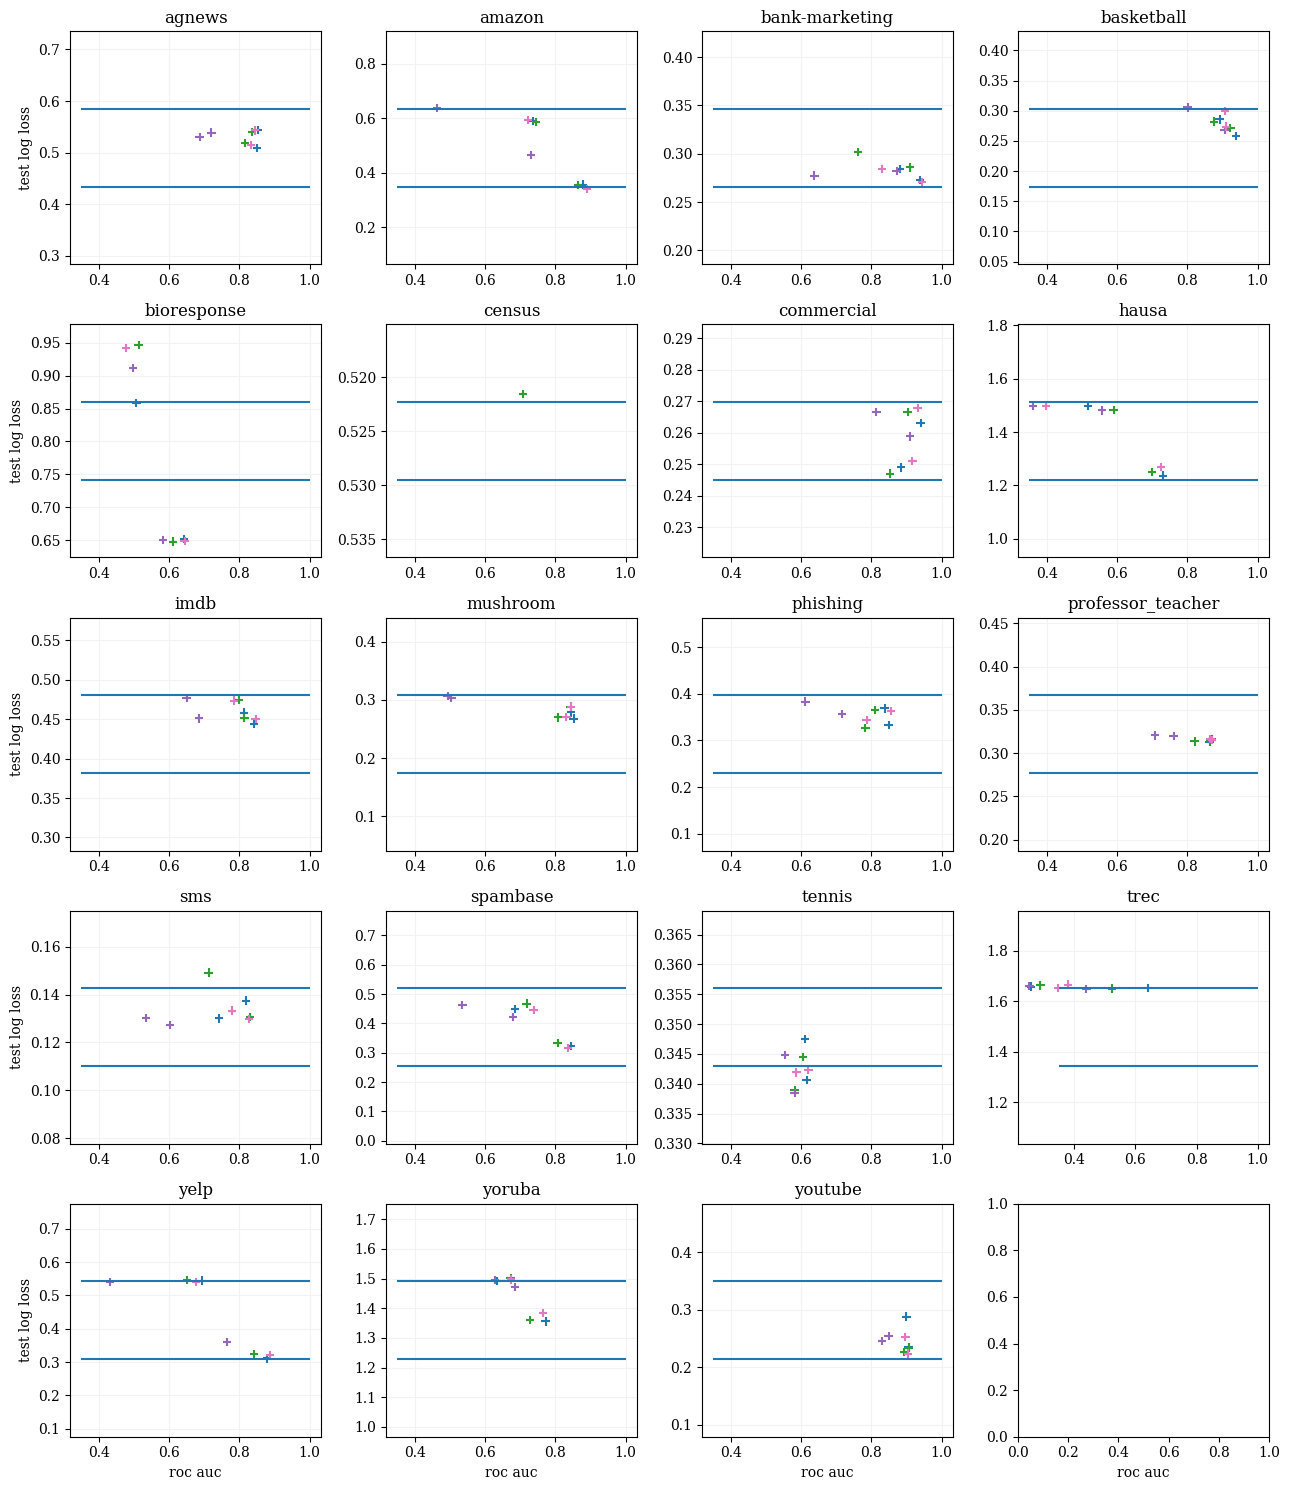

In [44]:
prefix = "weak/klm"
exp_alt = "allclass"


results_cv = all_results_cv[exp_alt][prefix]["logl"]
logl_cv = all_val_cv[exp_alt][prefix]["logl"]
logl_cv_for_norm = all_val_cv["allclass"][prefix]["logl"]

roc_auc = results_cv["oracl"].pivot(
    index="detector_name", columns="dataset_name", values="global_ranking_quality"
)

n_per_row = 4
n_rows = math.ceil(len(datasets) / n_per_row)
fig, axes = plt.subplots(n_rows, n_per_row, figsize=(13, 3 * n_rows))

for i, dataset_name in enumerate(results_cv["oracl"].dataset_name.unique()):
    axis = axes[i // n_per_row, i % n_per_row]

    axis.set_title(dataset_name)

    d_colors = [full_detector_colors[d] for d in roc_auc.index]

    axis.scatter(
        roc_auc[dataset_name],
        logl_cv["oracl"][dataset_name],
        marker="+",
        c=d_colors,
    )

    perf_none = logl_cv_for_norm["oracl"][dataset_name]["none"]
    perf_silver = logl_cv_for_norm["oracl"][dataset_name]["silver"]
    axis.hlines(perf_none, 0.35, 1)
    axis.hlines(perf_silver, 0.35, 1)

    # axis.set_xlim(0.35, 1)
    print(perf_none, perf_silver)
    axis.set_ylim(2 * perf_silver - perf_none, 2 * perf_none - perf_silver)
    custom_grid(axis)

for axis in axes:
    axis[0].set_ylabel("test log loss")
for axis in axes[-1]:
    axis.set_xlabel("roc auc")

plt.tight_layout()
plt.show()

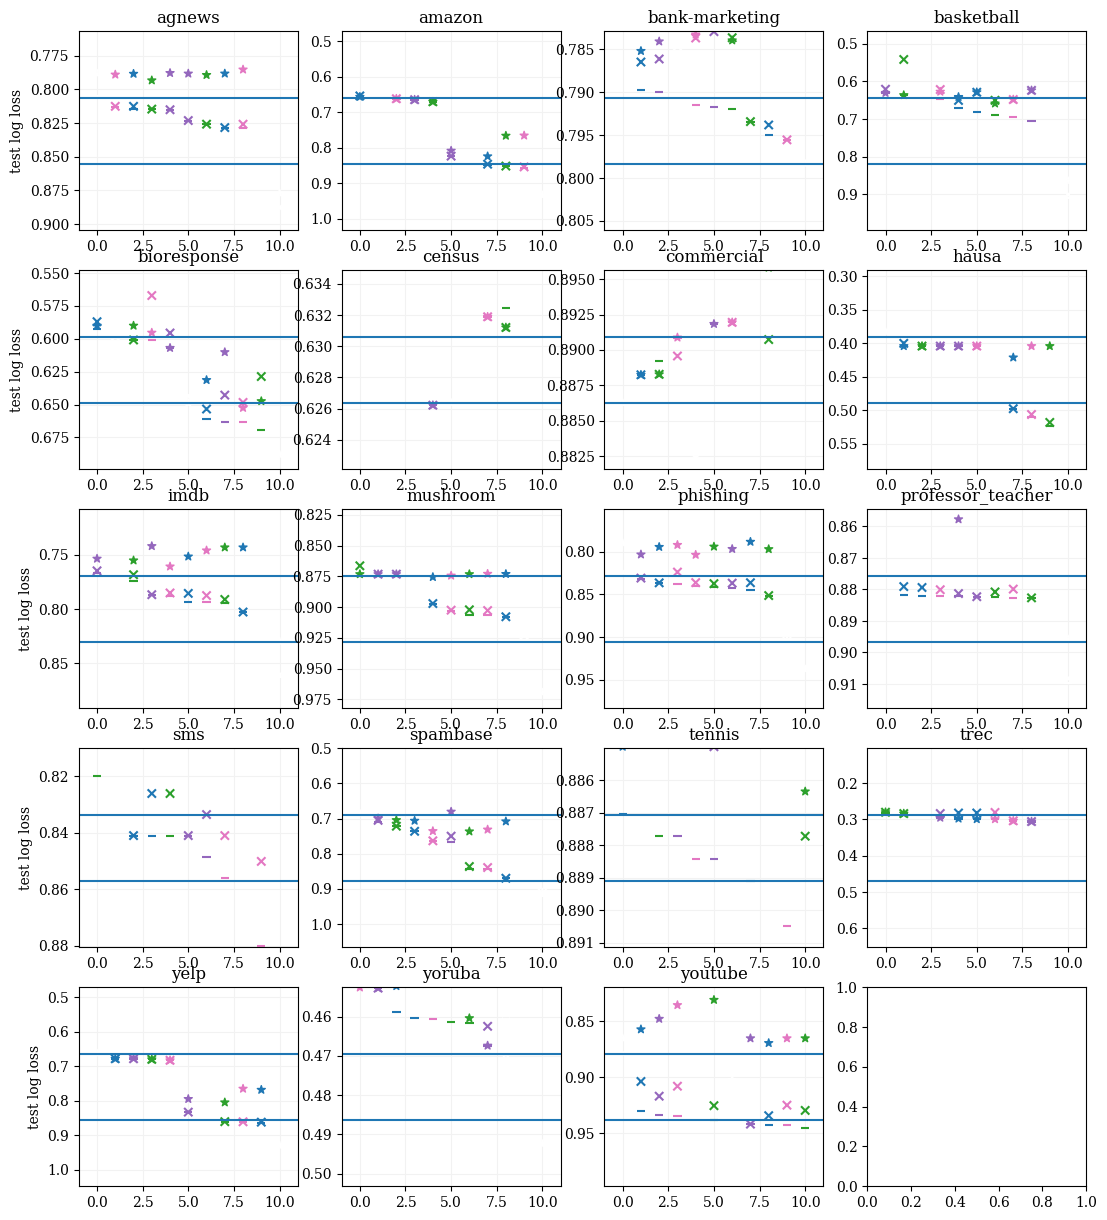

In [45]:
prefix = "weak/klm"
exp_alt = "allclass"

results_cv = all_results_cv[exp_alt][prefix]["bacc"]
logl_cv = all_val_cv[exp_alt][prefix]["bacc"]
logl_cv_for_norm = all_val_cv["allclass"][prefix]["bacc"]

n_per_row = 4
n_rows = math.ceil(len(datasets) / n_per_row)
fig, axes = plt.subplots(n_rows, n_per_row, figsize=(13, 3 * n_rows))

for i, dataset_name in enumerate(results_cv["oracl"].dataset_name.unique()):
    axis = axes[i // n_per_row, i % n_per_row]

    axis.set_title(dataset_name)

    sorted_indices = np.argsort(np.argsort(logl_cv["oracl"][dataset_name].values))
    n_detectors = len(sorted_indices)

    d_colors = [full_detector_colors[d] for d in logl_cv["oracl"][dataset_name].index]

    axis.scatter(
        sorted_indices,
        logl_cv["oracl"][dataset_name],
        marker="_",
        c=d_colors,
    )

    axis.scatter(
        sorted_indices,
        logl_cv["clean"][dataset_name],
        marker="x",
        c=d_colors,
    )

    axis.scatter(
        sorted_indices,
        logl_cv["noisy"][dataset_name],
        marker="*",
        c=d_colors,
    )

    perf_none = logl_cv_for_norm["oracl"][dataset_name]["none"]
    perf_silver = logl_cv_for_norm["oracl"][dataset_name]["silver"]
    axis.hlines(perf_none, -1, n_detectors)
    axis.hlines(perf_silver, -1, n_detectors)

    axis.set_ylim(2 * perf_silver - perf_none, 2 * perf_none - perf_silver)
    axis.set_xlim(-1, n_detectors)
    custom_grid(axis)

for axis in axes:
    axis[0].set_ylabel("test log loss")

if not os.path.exists("figures/summary"):
    os.mkdir("figures/summary/")

plt.savefig(f"figures/summary/{prefix.replace('/','_')}.pdf", bbox_inches="tight")
plt.show()

In [46]:
results_cv.keys()

dict_keys(['oracl', 'clean', 'noisy', 'noisy_10', 'noisy_90', 'clean_90', 'clean_10'])

In [47]:
hp_tune_str = {
    "clean": "HP tuned on noise free validation",
    "noisy": "HP tuned on noisy validation",
    "oracl": "Oracle HP",
    "noisy_10": "HP tuned on noisy validation, threshold forced at 10\%",
    "noisy_90": "HP tuned on noisy validation, training on 10\% top trusted",
    "clean_90": "HP tuned on clean validation, training on 10\% top trusted",
    "clean_10": "HP tuned on clean validation, training on 90\% top trusted",
}

strategy_str = {
    "allclass": "Filtering",
    "byclass": "Filtering by class",
    "relabel": "10\% relabeling",
}

oracl (1, 19) (1, 19) (11, 19)


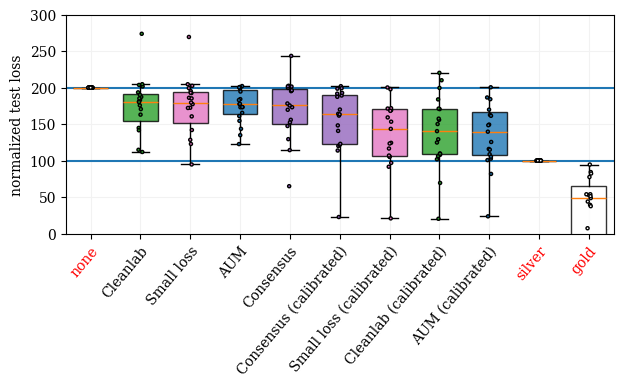

clean (1, 19) (1, 19) (11, 19)


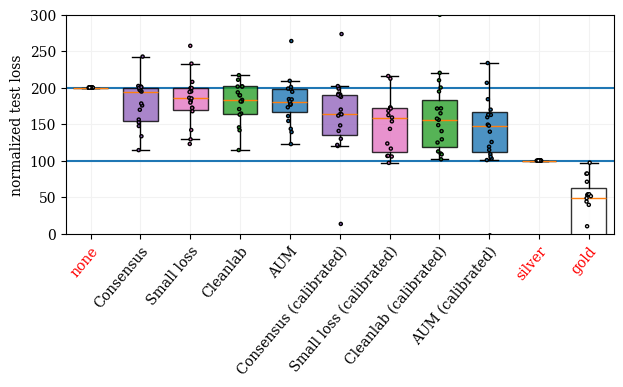

noisy (1, 19) (1, 19) (11, 19)


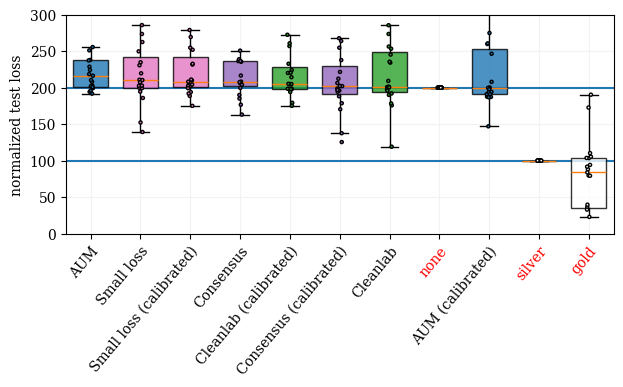

noisy_10 (1, 19) (1, 19) (10, 19)


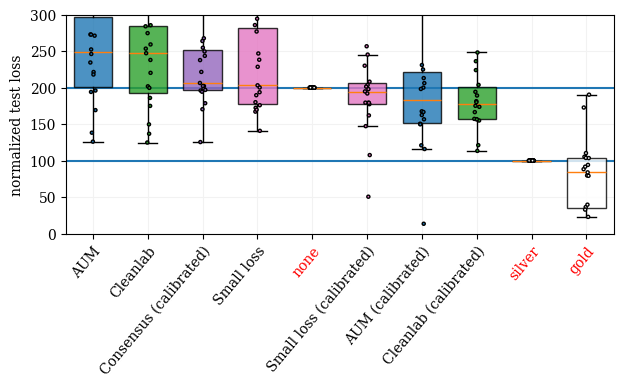

noisy_90 (1, 19) (1, 19) (10, 19)


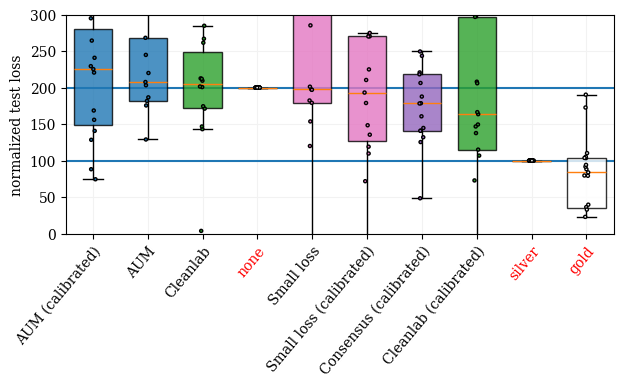

clean_90 (1, 19) (1, 19) (10, 19)


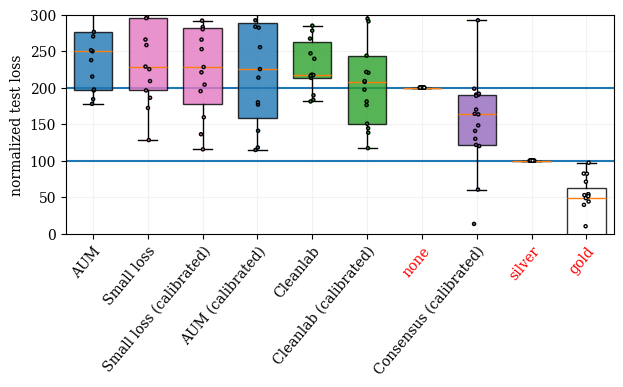

clean_10 (1, 19) (1, 19) (10, 19)


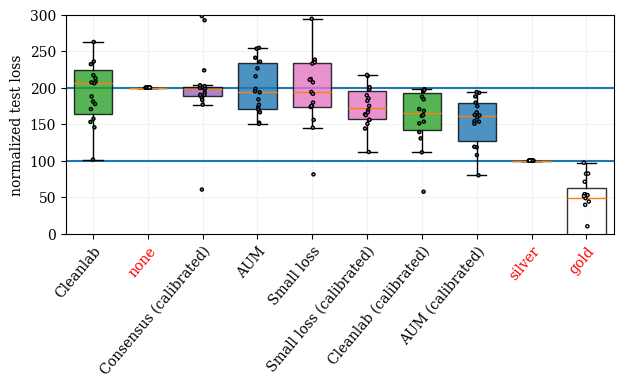

In [48]:
prefix = "weak/klm"
exp_alt = "allclass"
metric = "logl"

results_cv = all_results_cv[exp_alt][prefix][metric]
logl_cv = all_val_cv[exp_alt][prefix][metric]
logl_cv_for_norm = all_val_cv["allclass"][prefix][metric]

for k, r in results_cv.items():
    if exp_alt == "relabel" and k in ["noisy_10", "noisy_90", "clean_10", "clean_90"]:
        continue

    logl_cv_none = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "none"].values
    logl_cv_random = logl_cv[k].loc[logl_cv[k].index == "random"].values
    logl_cv_wood = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "wood"].values
    logl_cv_silver = (
        logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "silver"].values
    )
    logl_cv_gold = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "gold"].values

    # norm_low = (logl_cv_none + logl_cv_wood) / 2
    # norm_high = (logl_cv_silver + logl_cv_gold) / 2

    if False and exp_alt == "relabel":
        norm_low = logl_cv_random
    else:
        norm_low = logl_cv_none
    norm_high = logl_cv_silver

    print(k, norm_low.shape, norm_high.shape, logl_cv[k].shape)
    logl_cv_norm = (logl_cv[k] - norm_low) / (norm_high - norm_low + 1e-10)

    ordered_detectors = list(logl_cv_norm.median(axis=1).sort_values().index)
    ordered_detectors = [
        detector
        for detector in ordered_detectors
        if ("gb" not in detector) and ("nois" not in detector)
    ]
    # ordered_detectors = [
    #     detector for detector in ordered_detectors if (not "gb" in detector) and (not "forget" in detector) and (not "calib" in detector or "nois" in detector)
    # ]

    tf.figure(width=TMLR_textwidth * 0.95, pad=0.5)

    plt.axhline(100)
    plt.axhline(200)

    for i, detector_name in enumerate(ordered_detectors):
        d = logl_cv_norm.loc[logl_cv_norm.index == detector_name].values[0]
        # print(len(d))

        d_base100 = (2 - d) * 100
        d_base100 = d_base100[~np.isnan(d_base100)]
        bplot = plt.boxplot(
            [d_base100],
            positions=[i],
            # notch=True,
            # bootstrap=100,
            widths=[0.7],
            showfliers=False,
            patch_artist=True,
        )

        if np.any(np.isnan(d_base100)):
            ccc

        bplot["boxes"][0].set_facecolor(full_detector_colors[detector_name])
        bplot["boxes"][0].set_alpha(0.8)

        eps = 0.05
        plt.scatter(
            [i] * len(d_base100) + np.random.uniform(-eps, eps, size=len(d_base100)),
            d_base100,
            facecolors=[full_detector_colors[detector_name]] * len(d_base100),
            edgecolors="black",
            s=[5] * len(d_base100),
            zorder=10,
        )

    pretty_xticks = []
    for s in ordered_detectors:
        if s in baselines + ["random"]:
            pretty_xticks.append(s.replace("_", "\\_"))
        else:
            pretty_xticks.append(
                " ".join([detect_pretty_name[d] for d in d_detect_map[s].split(" ")])
                # + f" ({bm_pretty_name[d_base_model_map[s]]})"
            )
    plt.xticks(
        range(len(ordered_detectors)),
        pretty_xticks,
        rotation=50,
        rotation_mode="anchor",
        ha="right",
    )

    for i, detector_name in enumerate(ordered_detectors):
        if detector_name in baselines:
            plt.gca().get_xticklabels()[i].set_color("red")
        elif detector_name in ["random"]:
            plt.gca().get_xticklabels()[i].set_color("blue")

    plt.ylim(0, 300)
    custom_grid(plt.gca())
    # plt.title(f"Hyperparameters tuned using {hp_tune_str[k]} | {prefix} | {exp_alt}")
    plt.ylabel("normalized test loss")

    noise_str = "NCAR" if prefix.split("/")[0] == "noise" else "NNAR"
    classif_str = (
        "Linear Classifier"
        if prefix.split("/")[1] == "klm"
        else "Gradient Boosting Classifier"
    )
    # plt.suptitle(f"{hp_tune_str[k]}")
    # plt.suptitle(
    #     f"{noise_str} | {strategy_str[exp_alt]} | {classif_str} | {hp_tune_str[k]}"
    # )

    if not os.path.exists("figures/detectors"):
        # os.mkdir("figures")
        os.mkdir("figures/detectors/")

    tf.savefig(f"figures/detectors/{prefix.replace('/', '_')}_{exp_alt}_{k}_{metric}")

    plt.show()

In [49]:
prefix = "weak/klm"
exp_alt = "allclass"
metric = "logl"

results_cv = all_results_cv[exp_alt][prefix][metric]
logl_cv = all_val_cv[exp_alt][prefix][metric]
logl_cv_for_norm = all_val_cv["allclass"][prefix][metric]

import seaborn as sns
import itertools
from matplotlib.patches import Patch

for k, r in results_cv.items():
    if exp_alt == "relabel" and k in ["noisy_10", "noisy_90", "clean_10", "clean_90"]:
        continue

    logl_cv_none = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "none"].values
    # logl_cv_random = logl_cv[k].loc[logl_cv[k].index == "random"].values
    # logl_cv_wood = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "wood"].values
    logl_cv_silver = (
        logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "silver"].values
    )
    # logl_cv_gold = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "gold"].values

    # norm_low = (logl_cv_none + logl_cv_wood) / 2
    # norm_high = (logl_cv_silver + logl_cv_gold) / 2

    if False and exp_alt == "relabel":
        norm_low = logl_cv_random
    else:
        norm_low = logl_cv_none
    norm_high = logl_cv_silver

    print(k, norm_low.shape, norm_high.shape, logl_cv[k].shape)
    logl_cv_norm = (logl_cv[k] - norm_low) / (norm_high - norm_low + 1e-10)
    logl_cv_norm = (2 - logl_cv_norm) * 100

    df_sns_format = pd.melt(
        logl_cv_norm.reset_index(),
        id_vars="detector_name",
        value_vars=logl_cv_norm.columns,
    )
    non_baseline_mask = ~df_sns_format["detector_name"].isin(
        ["none", "silver", "gold", "random"]
    )
    df_sns_format.loc[non_baseline_mask, "calibration_size"] = (
        df_sns_format.loc[non_baseline_mask, "detector_name"].str.split("_").str[-1]
    ).astype(float)
    df_sns_format.loc[non_baseline_mask, "detector_name"] = (
        df_sns_format.loc[non_baseline_mask, "detector_name"]
        .str.split("_")
        .str[:-1]
        .str.join("_")
    )

    ordered_detectors = sorted(
        df_sns_format.loc[non_baseline_mask, "detector_name"].unique()
    )
    ordered_calibration_sizes = sorted(
        df_sns_format.loc[non_baseline_mask, "calibration_size"].unique()
    )

    tf.figure(width=TMLR_textwidth * 0.95, pad=0.5)

    plt.axhline(100)
    plt.axhline(200)

    ax = sns.boxplot(
        df_sns_format[non_baseline_mask],
        x="detector_name",
        y="value",
        hue="calibration_size",
        # hue_order=df_sns_format.loc[non_baseline_mask, "calibration_size"].sort_values(),
        showfliers=False,
        **{
            "boxprops": {"edgecolor": "black"},
            "medianprops": {"color": "black"},
            "whiskerprops": {"color": "black"},
            "capprops": {"color": "black"},
        },
        legend=False,
        # palette=sum(
        #     [
        #         sns.light_palette(
        #             full_detector_colors[d + "_0.1"],
        #             n_colors=len(ordered_calibration_sizes),
        #         )
        #         for d in ordered_detectors
        #     ],
        #     [],
        # ),
        # palette = {d: full_detector_colors[d+"_0.1"] for d in df_sns_format.loc[non_baseline_mask, "detector_name"].unique()}
        # boxprops={}
    )

    print(ordered_calibration_sizes)

    for i, box in enumerate(ax.patches):
        if i >= len(ordered_calibration_sizes) * len(ordered_detectors):
            break
        i, j = i % len(ordered_detectors), i // len(ordered_detectors)
        palette = sns.light_palette(
            full_detector_colors[ordered_detectors[i] + "_0.2"],
            n_colors=len(ordered_calibration_sizes),
        )
        box.set_facecolor(palette[j])

    ax2 = sns.stripplot(
        df_sns_format[non_baseline_mask],
        x="detector_name",
        y="value",
        hue="calibration_size",
        dodge=True,
        size=3,
        # ax=ax,
        edgecolor="black",
        linewidth=1,
        legend=False,
        ax=ax,
    )

    for i, box in enumerate(ax2.collections):
        if i >= len(ordered_calibration_sizes) * len(ordered_detectors):
            break
        i, j = i % len(ordered_calibration_sizes), i // len(ordered_calibration_sizes)
        palette = sns.light_palette(
            full_detector_colors[ordered_detectors[j] + "_0.2"],
            n_colors=len(ordered_calibration_sizes),
        )
        box.set_facecolor(palette[i])

    # for i, detector_name in enumerate(ordered_detectors):
    #     d = logl_cv_norm.loc[logl_cv_norm.index == detector_name].values[0]
    #     # print(len(d))

    #     d_base100 = (2 - d) * 100
    #     d_base100 = d_base100[~np.isnan(d_base100)]
    #     bplot = plt.boxplot(
    #         [d_base100],
    #         positions=[i],
    #         # notch=True,
    #         # bootstrap=100,
    #         widths=[0.7],
    #         showfliers=False,
    #         patch_artist=True,
    #     )

    #     if np.any(np.isnan(d_base100)):
    #         ccc

    #     bplot["boxes"][0].set_facecolor(full_detector_colors[detector_name])
    #     bplot["boxes"][0].set_alpha(0.8)

    #     eps = 0.05
    #     plt.scatter(
    #         [i] * len(d_base100) + np.random.uniform(-eps, eps, size=len(d_base100)),
    #         d_base100,
    #         facecolors=[full_detector_colors[detector_name]] * len(d_base100),
    #         edgecolors="black",
    #         s=[5] * len(d_base100),
    #         zorder=10,
    #     )

    pretty_xticks = []
    for s in ordered_detectors:
        if s in baselines + ["random"]:
            pretty_xticks.append(s.replace("_", "\\_"))
        else:
            pretty_xticks.append(
                " ".join([detect_pretty_name[d] for d in s.split("_")[1:-1]])
            )
    plt.xticks(
        range(len(ordered_detectors)),
        pretty_xticks,
        rotation=50,
        rotation_mode="anchor",
        ha="right",
    )

    # for i, detector_name in enumerate(ordered_detectors):
    #     if detector_name in baselines:
    #         plt.gca().get_xticklabels()[i].set_color("red")
    #     elif detector_name in ["random"]:
    #         plt.gca().get_xticklabels()[i].set_color("blue")

    plt.ylim(0, 300)
    custom_grid(plt.gca())
    # # plt.title(f"Hyperparameters tuned using {hp_tune_str[k]} | {prefix} | {exp_alt}")
    plt.ylabel("normalized test loss")
    plt.xlabel("")

    # plt.legend(
    #     handles=[
    #         Patch(facecolor=palette[i], edgecolor="black", label=f"{int(100 * float(c))}%")
    #         for i, c in enumerate(ordered_calibration_sizes)
    #     ],
    # )

    # noise_str = "NCAR" if prefix.split("/")[0] == "noise" else "NNAR"
    # classif_str = (
    #     "Linear Classifier"
    #     if prefix.split("/")[1] == "klm"
    #     else "Gradient Boosting Classifier"
    # )
    # # plt.suptitle(f"{hp_tune_str[k]}")
    # # plt.suptitle(
    # #     f"{noise_str} | {strategy_str[exp_alt]} | {classif_str} | {hp_tune_str[k]}"
    # # )

    if not os.path.exists("figures/calib_size2"):
        # os.mkdir("figures")
        os.mkdir("figures/calib_size2/")

    tf.savefig(f"figures/calib_size2/{prefix.replace('/','_')}_{exp_alt}_{k}_{metric}")

    plt.show()

oracl (1, 19) (1, 19) (11, 19)


ValueError: could not convert string to float: 'aum'

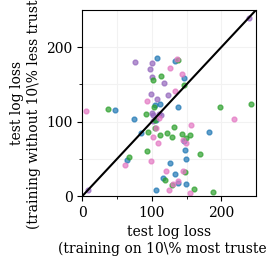

In [51]:
def plot_clean10_vs_clean90(prefix, exp_alt, k="clean"):
    logl_cv_for_norm = all_val_cv[exp_alt][prefix]["logl"]

    norm_low = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "none"].values
    norm_high = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "silver"].values

    logl_cv_clean10 = all_val_cv[exp_alt][prefix]["logl"]["clean_10"]
    logl_cv_clean90 = all_val_cv[exp_alt][prefix]["logl"]["clean_90"]

    logl_cv_clean10 = (logl_cv_clean10 - norm_low) / (norm_high - norm_low + 1e-10)
    logl_cv_clean90 = (logl_cv_clean90 - norm_low) / (norm_high - norm_low + 1e-10)

    logl_cv_clean10 = (logl_cv_clean10 + 1) * 100
    logl_cv_clean90 = (logl_cv_clean90 + 1) * 100

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines):

        perf_clean10 = logl_cv_clean10.loc[logl_cv_clean10.index == detector]
        perf_clean90 = logl_cv_clean90.loc[logl_cv_clean90.index == detector]

        plt.scatter(
            perf_clean10,
            perf_clean90,
            color=full_detector_colors[detector],
            marker=full_detector_markers[detector],
            s=12,
            alpha=0.7,
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([xy_min, xy_max], [xy_min, xy_max], color="black")
    plt.xlabel("test log loss\n(training on 10\% most trusted)")
    plt.ylabel("test log loss\n(training without 10\% less trusted)")

    custom_grid(plt.gca())
    plt.xlim(0, 250)
    plt.ylim(0, 250)
    # plt.xscale("log")
    # plt.yscale("log")

    plt.xticks(np.arange(0, 250, 50), [], minor=True)
    plt.yticks(np.arange(0, 250, 50), [], minor=True)
    plt.xticks([0, 100, 200], [0, 100, 200], minor=False)
    plt.yticks([0, 100, 200], [0, 100, 200], minor=False)
    # plt.grid()

    tf.savefig(f"figures/top_vs_bottom/{prefix.replace('/','_')}")
    plt.show()


if not os.path.exists(os.path.join("figures", "top_vs_bottom")):
    os.mkdir(os.path.join("figures", "top_vs_bottom"))

plot_clean10_vs_clean90(prefix="weak/klm", exp_alt="allclass")

In [ ]:
def plot_perf_clean_vs_noisy_calib(suffix, k, exp_alt):
    logl_cv_weak = all_val_cv[exp_alt]["weak" + suffix]["logl"][k]

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines) - set(["random"]):

        if "adjusted" in detector or "calibrated" in detector or "nois" in detector or "gb" in detector or "forget" in detector:
            continue

        print(detector)

        perf_noise = logl_cv_weak.loc[logl_cv_weak.index == f"{detector}_noisy"]
        perf_clean = logl_cv_weak.loc[logl_cv_weak.index == detector]

        if perf_noise.shape != perf_clean.shape:
            return None

        plt.scatter(
            perf_noise,
            perf_clean,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            # marker=full_detector_markers[detector],
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([xy_min, xy_max], [xy_min, xy_max], color="black")
    plt.xlabel("test log loss\n(noisy calibration set)")
    plt.ylabel("test log loss\n(clean calibration set)")

    custom_grid(plt.gca())
    plt.xlim(1e-1, 1)
    plt.ylim(1e-1, 1)
    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)
    # plt.grid()

    tf.savefig(f"figures/perf_clean_vs_noisy_calib/{exp_alt}{suffix.replace('/','_')}")
    plt.show()


if not os.path.exists("figures/perf_clean_vs_noisy_calib"):
    os.mkdir("figures/perf_clean_vs_noisy_calib")

plot_perf_clean_vs_noisy_calib(suffix="/klm", k="clean", exp_alt="allclass")

klm_aum


<Figure size 260.051x260.051 with 0 Axes>

klm_aum


ValueError: x and y must be the same size

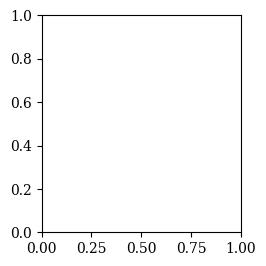

In [ ]:
def plot_perf_clean_vs_noisy_calib(suffix, k, exp_alt):
    logl_cv_weak = all_val_cv[exp_alt]["weak" + suffix]["logl"][k]

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines) - set(["random"]):


        if "adjusted" in detector or "calibrated" in detector or "nois" in detector or "gb" in detector or "forget" in detector:
            continue

        print(detector)

        perf_nothing = logl_cv_weak.loc[logl_cv_weak.index == f"{detector}"]
        perf_noise = logl_cv_weak.loc[logl_cv_weak.index == f"{detector}_calibrated_noisy"]
        perf_clean = logl_cv_weak.loc[logl_cv_weak.index == f"{detector}_calibrated"]

        if perf_noise.shape != perf_clean.shape:
            return None
                
        plt.scatter(
            perf_nothing,
            perf_clean,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            # marker=full_detector_markers[detector],
        )
        plt.scatter(
            perf_nothing,
            perf_noise,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            marker="x",
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([0.1, 2], [0.1, 2], color="black")
    plt.xlabel("test log loss\n(baseline detector)")
    plt.ylabel("test log loss\n(calibrated detector)")

    custom_grid(plt.gca())
    plt.xlim(1e-1, 2)
    plt.ylim(1e-1, 2)
    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(np.append(np.arange(0.1, 1, 0.1),2), [], minor=True)
    plt.yticks(np.append(np.arange(0.1, 1, 0.1),2), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)
    # plt.grid()
    plt.scatter([], [], color="black", label=f"clean calib.", s=12)
    plt.scatter([], [], color="black", label=f"noisy calib.", marker="x", s=12)
    plt.legend()

    tf.savefig(f"figures/perf_clean_vs_noisy_calib_V2/{exp_alt}{suffix.replace('/','_')}")
    plt.show()


if not os.path.exists("figures/perf_clean_vs_noisy_calib_V2"):
    os.mkdir("figures/perf_clean_vs_noisy_calib_V2")

plot_perf_clean_vs_noisy_calib(suffix="/klm", k="clean", exp_alt="allclass")

In [ ]:
def plot_nnar_vs_ncar(suffix, k, exp_alt):
    logl_cv_noise = all_val_cv[exp_alt]["noise" + suffix]["logl"][k]
    logl_cv_weak = all_val_cv[exp_alt]["weak" + suffix]["logl"][k]

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines):

        perf_noise = logl_cv_noise.loc[logl_cv_noise.index == detector]
        perf_weak = logl_cv_weak.loc[logl_cv_weak.index == detector]

        if perf_noise.shape != perf_weak.shape:
            continue

        plt.scatter(
            perf_noise,
            perf_weak,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            marker=full_detector_markers[detector],
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([xy_min, xy_max], [xy_min, xy_max], color="black")
    plt.xlabel("test log loss\n(NCAR dataset)")
    plt.ylabel("test log loss\n(NNAR dataset)")

    custom_grid(plt.gca())
    plt.xlim(1e-1, 1)
    plt.ylim(1e-1, 1)
    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)
    # plt.grid()

    tf.savefig(f"figures/weak_vs_noise/{exp_alt}{suffix.replace('/','_')}")
    plt.show()


plot_nnar_vs_ncar(suffix="/klm", k="oracl", exp_alt="allclass")

KeyError: 'noise/klm'

klm_consensus_calibrated_sigmoid_0.2
klm_aum_calibrated_sigmoid_0.2
klm_cleanlab_calibrated_sigmoid_0.2
klm_smallloss_calibrated_sigmoid_0.2


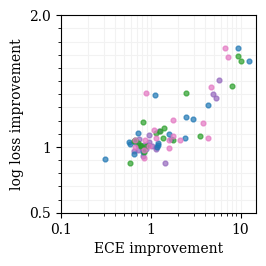

In [103]:
import re


def plot_improv_ece_improv_detect(prefix, k, exp_alt):
    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_model = (
        all_results[exp_alt][prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )

    ece = (
        all_results[exp_alt][prefix]
        .iloc[best_model]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values=f"ece_{mapping[k]}",
        )
    )

    logl = (
        all_results[exp_alt][prefix]
        .iloc[best_model]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values=f"logl_{mapping[k]}",
        )
    )

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines + ["random"]):
        if "calibrated" not in detector:
            continue

        print(detector)
        x = (
            ece.loc[ece.index == re.split("_calibrated", detector)[0]].values
            / ece.loc[ece.index == detector].values
        )

        y = (
            logl.loc[logl.index == re.split("_calibrated", detector)[0]].values
            / logl.loc[logl.index == detector].values
        )

        plt.scatter(
            x,
            y,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
        )

    # plt.plot([0, 0.5], [0, 0.5], color="black")

    plt.xlabel("ECE improvement")
    plt.ylabel("log loss improvement")

    plt.xscale("log")
    # plt.yscale("log")

    custom_grid(plt.gca())
    # plt.xlim(0.1, 100)
    plt.ylim(0.5, 2)

    # plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0.5, 2, 0.1), [], minor=True)
    plt.xticks([0.1, 1, 10], [0.1, 1, 10], minor=False)
    plt.yticks([0.5, 1, 2.0], [0.5, 1, 2.0], minor=False)

    tf.savefig(f"figures/improv_ece_improv_detect/{exp_alt}_{prefix.replace('/', '_')}")
    plt.show()


if not os.path.exists("figures/improv_ece_improv_detect"):
    os.mkdir("figures/improv_ece_improv_detect")

plot_improv_ece_improv_detect(prefix="weak/klm", k="oracl", exp_alt="allclass")

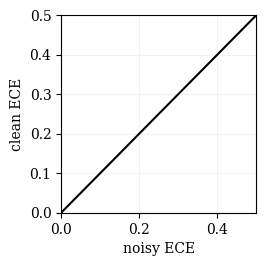

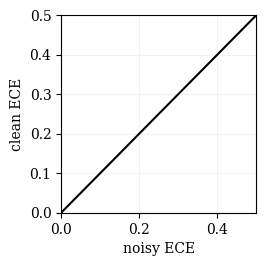

IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 260.051x260.051 with 0 Axes>

In [ ]:
def plot_calib_noisy_clean(prefix, k, exp_alt):

    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_model = (
        all_results[exp_alt][prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )

    ece = {}
    for eval_split in ["val", "test", "noisy_val"]:

        ece[eval_split] = (
            all_results[exp_alt][prefix]
            .iloc[best_model]
            .pivot(
                index="detector_name",
                columns="dataset_name",
                values=f"ece_{eval_split}",
            )
        )

    alternatives = ["adjusted", "calibrated"]

    for base in ["gb", "klm"]:

        for alternative in alternatives:
            tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

            for detector in set(detectors) - set(baselines + ["random"]):

                if not detector.startswith(base) or any(
                    detector.endswith(alternative) for alternative in alternatives
                ):
                    continue

                x1 = ece["noisy_val"].loc[ece["noisy_val"].index == detector]
                y1 = ece["val"].loc[ece["val"].index == detector]

                x2 = ece["noisy_val"].loc[
                    ece["noisy_val"].index == f"{detector}_{alternative}"
                ]
                y2 = ece["val"].loc[ece["val"].index == f"{detector}_{alternative}"]

                for i in range(len(x1.values.ravel())):
                    plt.annotate(
                        "",
                        (x2.values.ravel()[i], y2.values.ravel()[i]),
                        (x1.values.ravel()[i], y1.values.ravel()[i]),
                        arrowprops={
                            "arrowstyle": "->",
                            "color": colormaps["tab20"].colors[i],
                            "shrinkA": 0,
                            "shrinkB": 0,
                        },
                    )

            xlims, ylims = plt.xlim(), plt.ylim()
            xy_min = min(xlims[0], ylims[0])
            xy_max = max(xlims[1], ylims[1])

            plt.plot([0, 0.5], [0, 0.5], color="black")

            plt.xlabel("noisy ECE")
            plt.ylabel("clean ECE")

            custom_grid(plt.gca())
            plt.xlim(0, 0.5)
            plt.ylim(0, 0.5)

            tf.savefig(
                f"figures/calib_clean_vs_noisy/{exp_alt}_{prefix.replace('/','_')}_{alternative}_{base}"
            )
            plt.show()


if not os.path.exists("figures/calib_clean_vs_noisy"):
    os.mkdir("figures/calib_clean_vs_noisy")

plot_calib_noisy_clean(prefix="weak/klm", k="oracl", exp_alt="allclass")

FileNotFoundError: [Errno 2] No such file or directory: 'figures/clean_vs_noisy/allclass_weak_klm.pdf'

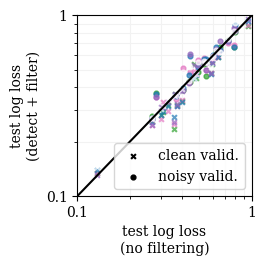

In [ ]:
def plot_clean_noisy(prefix, exp_alt):
    logl_cv_noisy = all_val_cv[exp_alt][prefix]["logl"]["noisy"]
    logl_cv_clean = all_val_cv[exp_alt][prefix]["logl"]["clean"]
    logl_cv_noisy_none = logl_cv_noisy.loc[logl_cv_noisy.index == "none"]
    logl_cv_clean_none = logl_cv_clean.loc[logl_cv_clean.index == "none"]

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines):

        perf_noisy = logl_cv_noisy.loc[logl_cv_noisy.index == detector]
        perf_clean = logl_cv_clean.loc[logl_cv_clean.index == detector]

        plt.scatter(
            logl_cv_noisy_none,
            perf_noisy,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
        )

        plt.scatter(
            logl_cv_clean_none,
            perf_clean,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            marker="x",
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([xy_min, xy_max], [xy_min, xy_max], color="black")

    plt.xlabel("test log loss\n(no filtering)")
    plt.ylabel("test log loss\n(detect + filter)")

    custom_grid(plt.gca())
    plt.xlim(1e-1, 1)
    plt.ylim(1e-1, 1)
    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)

    plt.scatter([], [], color="black", label=f"clean valid.", marker="x", s=12)
    plt.scatter([], [], color="black", label=f"noisy valid.", s=12)
    plt.legend()

    tf.savefig(f"figures/clean_vs_noisy/{exp_alt}_{prefix.replace('/','_')}")
    plt.show()


plot_clean_noisy(prefix="weak/klm", exp_alt="allclass")

In [46]:
from sklearn.linear_model import HuberRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

regr = make_pipeline(PolynomialFeatures(1), HuberRegressor())

/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_53828/3115410098.py:50: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_53828/3115410098.py:50: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_53828/3115410098.py:50: UserWarning: *c* argument looks like a single numeric RGB or 

FileNotFoundError: [Errno 2] No such file or directory: 'figures/perf_vs_detect/weak_klm_allclass.pdf'

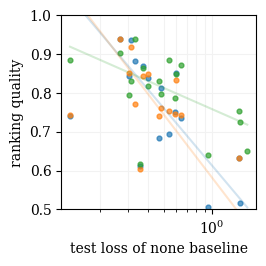

In [47]:
prefix = "weak/klm"
estim = prefix.split("/")[-1]
exp_alt = "allclass"

r_none = all_results_cv[exp_alt][prefix]["logl"]["oracl"][
    all_results_cv[exp_alt][prefix]["logl"]["oracl"]["detector_name"] == "none"
]

r_qualities = defaultdict(list)
none_losses = defaultdict(list)

for detect_name, dataset_name, ranking_quality in all_results_cv[exp_alt][prefix][
    "logl"
]["oracl"][["detector_name", "dataset_name", "global_ranking_quality"]].itertuples(
    index=False
):

    if detect_name in baselines + ["random"]:
        continue

    # if ranking_quality < 0.5:
    #     continue

    if estim != d_base_model_map[detect_name]:
        continue

    # if detect_name != 'agra': continue

    assert len(r_none[r_none["dataset_name"] == dataset_name]) == 1
    logl_test_none = r_none[r_none["dataset_name"] == dataset_name].iloc[0]["logl_test"]

    r_qualities[detect_name].append(ranking_quality)
    none_losses[detect_name].append(logl_test_none)


tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)
custom_grid(plt.gca())

plt.xlabel(f"test loss of none baseline")
plt.ylabel(f"ranking quality")
plt.xscale("log")
plt.yscale("linear")


def t(x):
    return np.log(x)


for (d_name, r_quals), (_, none_los) in zip(r_qualities.items(), none_losses.items()):
    plt.scatter(
        none_los,
        r_quals,
        c=full_detector_colors[d_name],
        marker=full_detector_markers[d_name],
        alpha=0.7,
        s=12,
    )

    none_los, r_quals = zip(*sorted(zip(none_los, r_quals)))
    # plt.plot(none_los, r_quals, c=detector_colors[d_name], alpha=0.1)

    regr.fit(t(np.array(none_los)[:, None]), r_quals)

    x_plot = np.linspace(np.min(none_los), np.max(none_los))
    plt.plot(
        x_plot,
        regr.predict(t(x_plot[:, None])),
        c=full_detector_colors[d_name],
        alpha=0.2,
    )

# xlims = plt.xlim()
# ylims = plt.ylim()

# rmin = min(xlims[0], ylims[0])
# rmax = max(xlims[1], ylims[1])

# plt.plot([rmin, rmax], [rmin, rmax], color="black")

plt.ylim(0.5, 1)
# plt.ylim(rmin, rmax)

tf.savefig(f"figures/perf_vs_detect/{prefix.replace('/','_')}_{exp_alt}")
plt.show()

In [ ]:
remaining = dict()

n = 12

for ds, n_runs in (
    all_results['byclass']["weak/klm"].pivot_table(
        index="detector_name",
        columns="dataset_name",
        values="estim_time",
        aggfunc="count",
    )
).items():

    # remaining[ds] = (8*12*10 - n_runs[np.logical_and(n_runs < 8*12*10, ~n_runs.isin([12, 120]))]).sum()
    # remaining[ds] = (9*12 - n_runs[np.logical_and(n_runs <9*12, ~n_runs.isin([12, 120]))]).sum()
    # remaining[ds] = int(
    #     (
    #         n * 12 * 10
    #         - n_runs[np.logical_and(~n_runs.isin([12, 120]), n_runs < n * 12 * 10)]
    #     ).sum()
    # )

    # remaining[ds] += 1440*2

    remaining[ds] = int(16*1440+4*12+120 - n_runs.sum())

    # if remaining[ds]> 0:
    #     remaining[ds] += 100

    # print(ds, n_runs, remaining[ds])
    print(ds, remaining[ds])

In [ ]:
datasets_with_rbf = [
    "bank-marketing",
    "bioresponse",
    "census",
    "mushroom",
    "phishing",
    "spambase",
    "basketball",
    "commercial",
    "tennis",
    "cifar10",
]

In [ ]:
classif = "klm"

all_results['allclass'][f"weak/{classif}"].pivot_table(
    index="dataset_name",
    columns="detector_name",
    values="estim_time",
    aggfunc="max",
    # aggfunc=lambda x: np.percentile(x, 15),
)["white_gold"].sort_values(ascending=False)

In [ ]:
# for d in [
#     "bank-marketing",
#     "bioresponse",
#     "census",
#     "mushroom",
#     "phishing",
#     "spambase",
#     "basketball",
#     "commercial",
#     "tennis",
#     "cifar10",
# ]:
#     for k in ["estim", "estim_byclass", "relabel"]:
#         for n in ["weak", "noise"]:
#             print(f"ls {k}/{n}/klm/*/{d}.json")

In [ ]:
for k in all_results_cv["allclass"].keys():
    d = all_results_cv["allclass"][k]["logl"]["clean"]

    print(k)
    for d_name, detector_name, params_classifier, params_detector in d[
        ["dataset_name", "detector_name", "params_classifier", "params_detector"]
    ].itertuples(index=False):
        if (
            detector_name in d_base_model_map.keys()
            and d_base_model_map[detector_name] == "klm"
        ):
            # print(d_base_model_map[detector_name] )
            print(d_name, detector_name, params_detector, params_classifier)

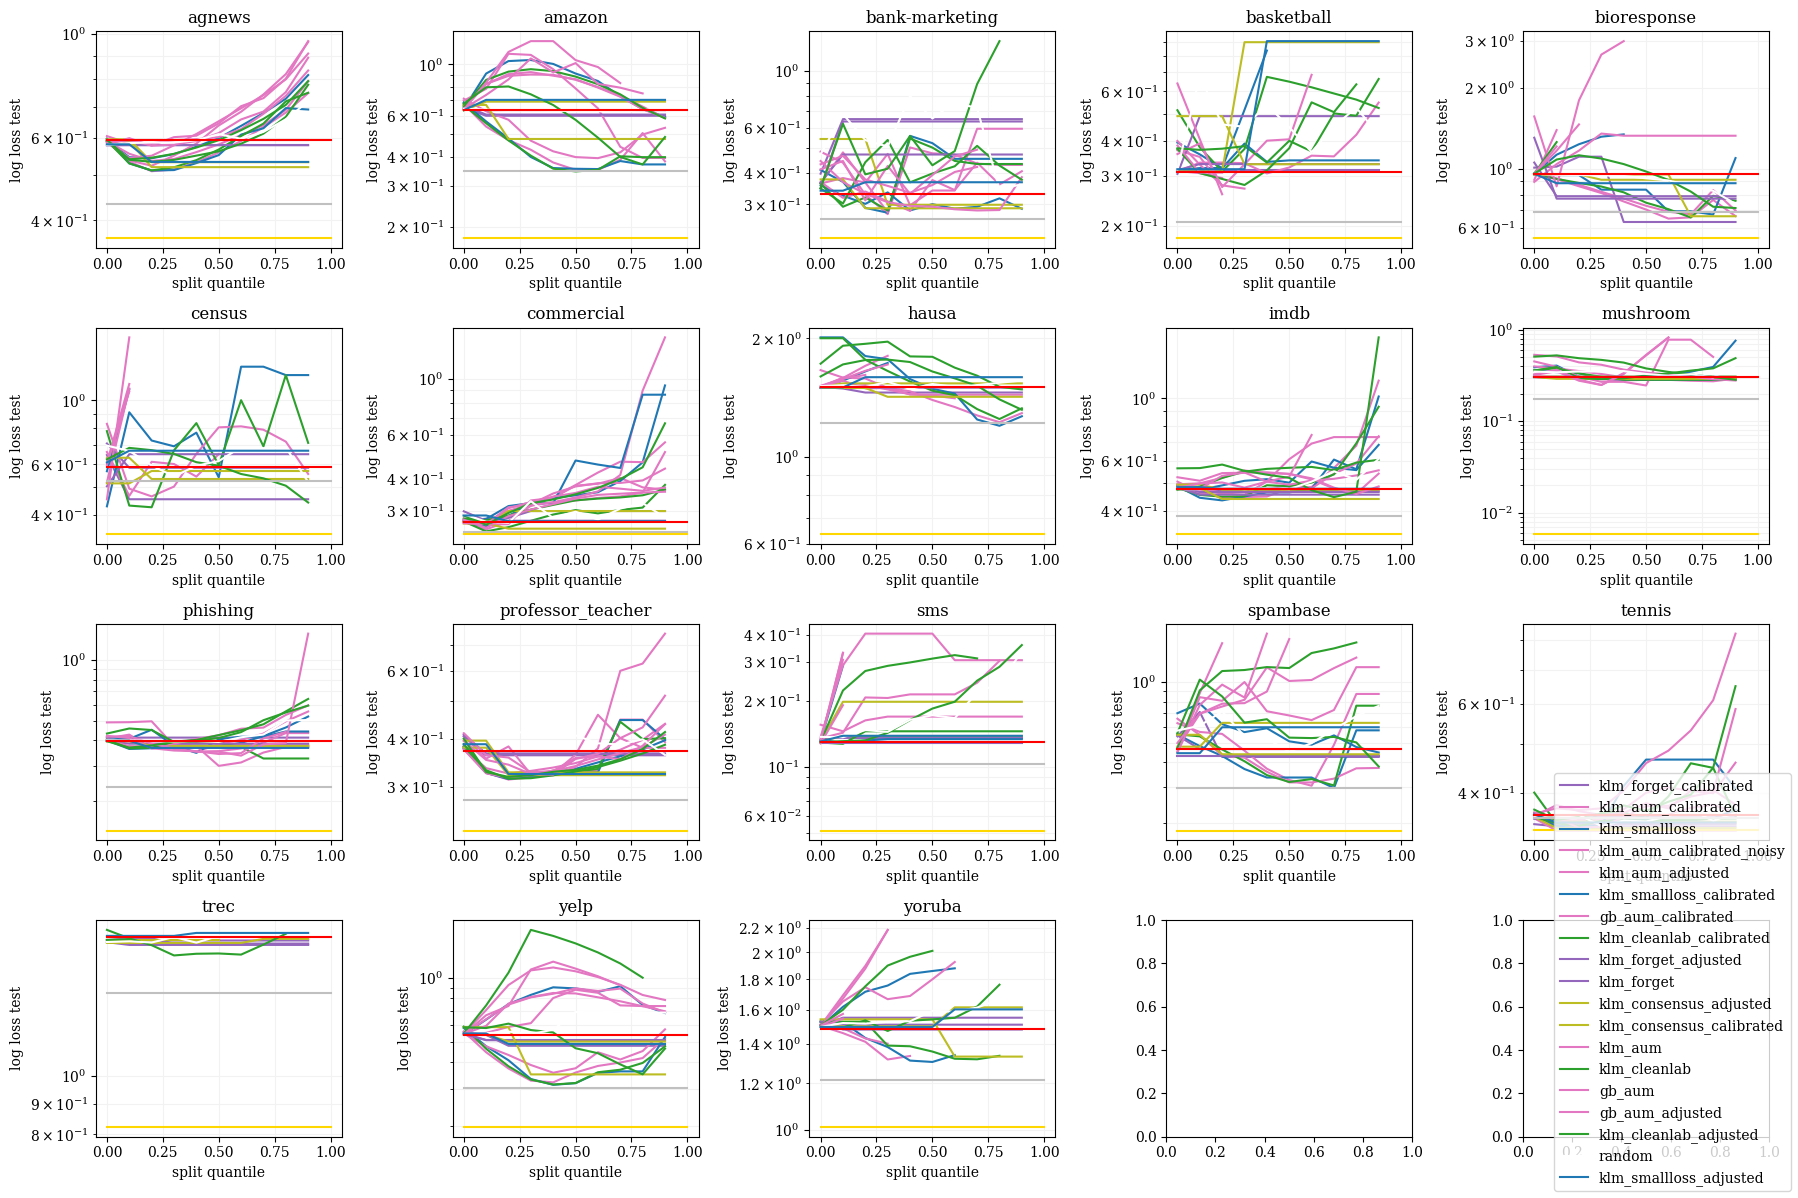

In [255]:
prefix = "weak/klm"
exp_alt = "allclass"

hp_pivot = all_results_cv[exp_alt][prefix]["logl"]["clean"].pivot(
    values="params_classifier", index="dataset_name", columns="detector_name"
)
res = all_results[exp_alt][prefix]
res_none = all_results_cv[exp_alt][prefix]["logl"]["clean"][
    all_results_cv[exp_alt][prefix]["logl"]["clean"]["detector_name"] == "none"
][["dataset_name", "logl_test"]].set_index("dataset_name")
res_silver = all_results_cv[exp_alt][prefix]["logl"]["clean"][
    all_results_cv[exp_alt][prefix]["logl"]["clean"]["detector_name"] == "silver"
][["dataset_name", "logl_test"]].set_index("dataset_name")
res_gold = all_results_cv[exp_alt][prefix]["logl"]["clean"][
    all_results_cv[exp_alt][prefix]["logl"]["clean"]["detector_name"] == "gold"
][["dataset_name", "logl_test"]].set_index("dataset_name")

mult = 1.5
fig, axes = plt.subplots(4, 5, figsize=(12 * mult, 8 * mult))

for i, dataset in enumerate(datasets):
    axis = axes[i // 5][i % 5]

    for detector in set(detectors) - {"gb_consensus", "klm_consensus"} - set(baselines):
        hp_this = hp_pivot.loc[dataset][detector]
        logl_this = res[(res.dataset_name == dataset) & (res.detector_name == detector)]
        logl_this = logl_this[logl_this.params_classifier.apply(lambda x: x == hp_this)]

        split_quantiles = []
        logls = []
        for p_split, logl in logl_this[["params_splitter", "logl_test"]].itertuples(
            index=False
        ):
            split_quantiles.append(p_split["quantile"])
            logls.append(logl)

        axis.plot(split_quantiles, logls, label=detector, color=full_detector_colors[detector])

    axis.plot([0, 1], [res_none.loc[dataset].values] * 2, color="red")
    axis.plot([0, 1], [res_silver.loc[dataset].values] * 2, color="silver")
    axis.plot([0, 1], [res_gold.loc[dataset].values] * 2, color="gold")

    custom_grid(axis)
    axis.set_title(dataset)
    # axis.legend()
    axis.set_xlabel("split quantile")
    axis.set_ylabel("log loss test")
    axis.set_xlim()
    axis.set_yscale("log")

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right')

fig.tight_layout()
plt.show()

In [294]:
detect_dirs = [
    (
        "weak",
        os.path.join(os.path.expanduser("~"), f"{output_dir}/../detect/weak"),
    ),
    # (
    #     "noise",
    #     os.path.join(os.path.expanduser("~"), f"{output_dir}/detect/noise"),
    # ),
]

exp_alt = "allclass"

all_detect = dict()
for prefix, dir in detect_dirs:
    results_ = []
    methods = os.listdir(dir)

    for method in methods:
        for fname in os.listdir(os.path.join(dir, method)):
            dataset, ext = fname.split(".")
            if ext != "json":
                continue

            with open(os.path.join(dir, method, f"{dataset}.json")) as f:
                results_.append(pd.read_json(f, orient="records"))

    results_ = pd.concat(results_)

    all_detect[prefix] = results_.reset_index(drop=True)
    all_detect[prefix]["detect_run"] = all_detect[prefix].groupby(["dataset_name", "detector_name"]).cumcount()+1

# for k, v in all_results[exp_alt].items():
#     v.loc[pd.isna(v["params_detector"]), "params_detector"] = v.loc[
#         pd.isna(v["params_detector"]), "params"
#     ]
#     v.drop("params", inplace=True, axis=1)

all_merged = dict()
# for prefix in ["weak", "noise"]:
for prefix in ["weak"]:
    all_results[exp_alt][prefix + "/klm"]["params_detector"] = all_results[exp_alt][prefix + "/klm"][
        "params_detector"
    ].astype(str)
    all_detect[prefix]["params"] = all_detect[prefix]["params"].astype(str)

    all_merged[prefix] = pd.merge(
        all_results[exp_alt][prefix + "/klm"],
        all_detect[prefix],
        left_on=["dataset_name", "detector_name", "params_detector"],
        right_on=["dataset_name", "detector_name", "params"],
    )

    all_merged[prefix]["params_detector"] = all_merged[prefix]["params_detector"].apply(
        eval
    )

In [266]:
detect_path = os.path.join(os.path.expanduser("~"), f"{output_dir}/../detect")
import json
import h5py
import numpy as np
import pandas as pd
from scipy.stats import entropy


class TrustScoreReader:

    def __init__(self, base_path, dataset, detector):

        with open(os.path.join(base_path, detector, f"{dataset}.json"), mode="r") as f:
            self.results_json = json.load(f)
        self.results_hdf5 = h5py.File(
            os.path.join(base_path, detector, f"{dataset}.hdf5"), "r"
        )

        assert len(self.results_hdf5["trust_scores"]) == len(self.results_json)

    def get(self, i):
        return self.results_json[i], self.results_hdf5[f"trust_scores/{i}"][...]

    def length(self):
        return len(self.results_json)

In [258]:
from datasets import get_weak_datasets, datasets_ranked_by_time
import os

datasets_folder = os.path.join(os.path.expanduser("~"), "datasets")

datasets = list(
    filter(
        lambda dataset: dataset not in ["imdb136", "cifar10"], datasets_ranked_by_time
    )
)

weak_datasets = get_weak_datasets(
    cache_folder=datasets_folder,
    corruption="weak",
    seed=1,
    datasets=datasets,
)

# noise_datasets = get_weak_datasets(
#     cache_folder=datasets_folder,
#     corruption="noise",
#     seed=1,
#     datasets=datasets_ranked_by_time,
# )

loaded_datasets = dict(weak=weak_datasets)

/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:74: RuntimeWarning: invalid value encountered in divide
  prior_untrusted = np.bincount(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:74: RuntimeWarning: divide by zero encountered in divide
  prior_untrusted = np.bincount(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:71: RuntimeWarning: invalid value encountered in divide
  prior_trusted = np.bincount(y_train_noisy[trusted], minlength=n_classes) / len(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:71: RuntimeWarning: divide by zero encountered in divide
  prior_trusted = np.bincount(y_train_noisy[trusted], minlength=n_classes) / len(


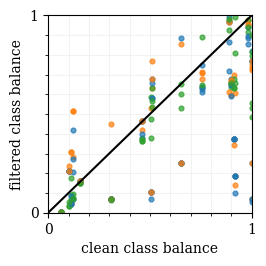

/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:74: RuntimeWarning: invalid value encountered in divide
  prior_untrusted = np.bincount(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:74: RuntimeWarning: divide by zero encountered in divide
  prior_untrusted = np.bincount(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:71: RuntimeWarning: invalid value encountered in divide
  prior_trusted = np.bincount(y_train_noisy[trusted], minlength=n_classes) / len(
/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_1510/2078350696.py:71: RuntimeWarning: divide by zero encountered in divide
  prior_trusted = np.bincount(y_train_noisy[trusted], minlength=n_classes) / len(


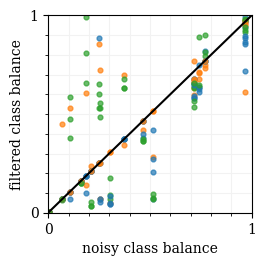

In [301]:
from itertools import product


def plot_class_balance(prefix, reference="clean", k="oracl", exp_alt="allclass"):

    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_cv = (
        all_merged[prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )
    best_trust_scores_index = (
        all_merged[prefix]
        .iloc[best_cv]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="detect_run",
        )
    )
    best_quantile = (
        all_merged[prefix]
        .iloc[best_cv]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="params_splitter",
        )
        .map(lambda dict: dict.get("quantile"))
    )
    best_threshold = (
        all_merged[prefix]
        .iloc[best_cv]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="params_splitter",
        )
        .map(lambda dict: dict.get("threshold"))
    )
    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    top = 0
    bottom = 0
    for detector_name, dataset_name in product(
        best_trust_scores_index.index, best_trust_scores_index.columns
    ):
        if "gb" in detector_name or "nois" in detector_name or "forg" in detector_name:
            continue

        trust_score_reader = TrustScoreReader(
            os.path.join(detect_path, prefix), dataset_name, detector_name
        )
        trust_scores = trust_score_reader.get(
            best_trust_scores_index.loc[detector_name, dataset_name] - 1
        )[1]
        dataset = loaded_datasets[prefix][dataset_name]
        y_train_clean = dataset["train"]["target"]
        y_train_noisy = dataset["train"]["noisy_target"]
        y_test = dataset["test"]["target"]
        unlabeled = y_train_noisy == -1
        y_train_clean = np.asarray(y_train_clean)[~unlabeled]
        y_train_noisy = np.asarray(y_train_noisy)[~unlabeled]
        n_classes = len(np.unique(y_test))
        if "consensus" in detector_name:
            trusted = trust_scores >= best_threshold.loc[detector_name, dataset_name]
        else:
            trusted = trust_scores >= np.quantile(
                trust_scores, q=best_quantile.loc[detector_name, dataset_name]
            )
        prior_trusted = np.bincount(y_train_noisy[trusted], minlength=n_classes) / len(
            y_train_noisy[trusted]
        )
        prior_untrusted = np.bincount(
            y_train_noisy[~trusted], minlength=n_classes
        ) / len(y_train_noisy[~trusted])
        prior_clean = np.bincount(y_test, minlength=n_classes) / len(y_test)
        prior_noisy = np.bincount(y_train_noisy, minlength=n_classes) / len(
            y_train_noisy
        )
        x_clean = np.min(prior_clean) / np.max(prior_clean)
        x_noisy = np.min(prior_noisy) / np.max(prior_noisy)
        x = x_clean if reference == "clean" else x_noisy
        y = np.min(prior_trusted) / np.max(prior_trusted)
        plt.scatter(
            x,
            y,
            # color="tab:blue" if x_noisy > x_clean else "tab:orange",
            # color=full_detector_colors[detector_name],
            color = "tab:orange" if "adjust" in detector_name else ("tab:green" if "calib" in detector_name else "tab:blue"),
            # marker=full_detector_markers[detector_name],
            # marker=(
            #     "x"
            #     if "adjust" in detector_name
            #     else ("o" if "calib" in detector_name else "s")
            # ),
            alpha=0.7,
            s=12,
        )
        top += np.sum(y > x)
        bottom += np.sum(y <= x)

    plt.ylabel("filtered class balance")
    if reference == "clean":
        plt.xlabel("clean class balance")
    else:
        plt.xlabel("noisy class balance")

    # plt.title(f"{top}/{bottom}")

    custom_grid(plt.gca())

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), color="black")

    plt.xticks(np.arange(0, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0, 1, 0.1), [], minor=True)
    plt.xticks([0, 1], [0, 1], minor=False)
    plt.yticks([0, 1], [0, 1], minor=False)

    # plt.scatter(
    #     [], [], color="tab:blue", label=f"more bal. than {mapping[k][0]}.", s=12
    # )
    # plt.scatter(
    #     [], [], color="tab:orange", label=f"less bal. than {mapping[k][0]}.", s=12
    # )
    # plt.legend()

    tf.savefig(f"figures/class_balance/{prefix.replace('/','_')}_{reference}")
    plt.show()


if not os.path.exists("figures/class_balance"):
    os.mkdir("figures/class_balance")
# plot_class_balance("noise", reference="clean")
# plot_class_balance("noise", reference="noisy")
plot_class_balance("weak", reference="clean")
plot_class_balance("weak", reference="noisy")

[-83.05588779]
-0.0014086452221833135


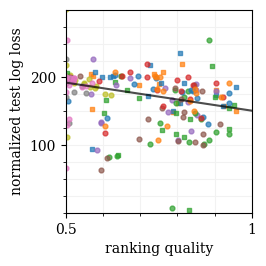

In [135]:
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR


def plot_rank_vs_perf(prefix, k, exp_alt="allclass"):
    logl_cv_allclass = all_val_cv[exp_alt][prefix]["logl"][k]
    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    max_rank_global = (
        all_results[exp_alt][prefix]
        .iloc[
            all_results[exp_alt][prefix]
            .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
            .idxmin()
        ]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="global_ranking_quality",
        )
    )
    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    list_perf_allclass = []
    list_perf_rank = []

    # plt.axvline(0.5, color=detector_colors["random"], alpha=0.7)

    for detector in set(detectors) - set(baselines) - set(["random"]):

        perf_allclass = (
            logl_cv_allclass.loc[logl_cv_allclass.index == detector].values
            - logl_cv_allclass.loc[logl_cv_allclass.index == "none"].values
        ) / (
            logl_cv_allclass.loc[logl_cv_allclass.index == "silver"].values
            - logl_cv_allclass.loc[logl_cv_allclass.index == "none"].values
            + 1e-10
        )
        perf_allclass = (2 - perf_allclass) * 100
        perf_rank = max_rank_global.loc[
            max_rank_global.index == detector
        ].values.ravel()

        plt.scatter(
            perf_rank,
            perf_allclass,
            color=full_detector_colors[detector],
            marker=full_detector_markers[detector],
            s=12,
            alpha=0.7,
        )
        
        list_perf_allclass.append(perf_allclass.ravel())
        list_perf_rank.append(perf_rank)

    plt.xlabel("ranking quality")
    plt.ylabel("normalized test log loss")

    custom_grid(plt.gca())

    plt.xlim(0.5, 1)
    plt.ylim(0, 300)

    y = np.concatenate(list_perf_allclass)
    X = np.concatenate(list_perf_rank).reshape(-1, 1)
    y = y[X.ravel() >= 0.5]
    X = X[X.ravel() >= 0.5]
    lr = HuberRegressor().fit(X, y)
    print(lr.coef_)
    print(r2_score(y, lr.predict(X)))

    x = np.linspace(0.5, 1, 1000)
    plt.plot(x, lr.predict(x.reshape(-1, 1)), color="black", alpha=0.7)

    plt.xticks(np.arange(0.5, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0, 300, 25), [], minor=True)
    plt.xticks([0.5, 1], [0.5, 1], minor=False)
    plt.yticks([100, 200], [100, 200], minor=False)

    tf.savefig(f"figures/rank_vs_perf/{prefix.replace('/','_')}")
    plt.show()


if not os.path.exists("figures/rank_vs_perf"):
    os.makedirs("figures/rank_vs_perf")

# plot_rank_vs_perf(prefix="noise/klm", k="oracl")
plot_rank_vs_perf(prefix="weak/klm", k="oracl")
# plot_rank_vs_perf(prefix="noise/gb", k="oracl")
# plot_rank_vs_perf(prefix="weak/gb", k="oracl")